Vamos a considerar una aproximación de bolsa de palabras junto con la normalización vista anteriormente para aproximar un clasificador de sentimientos, entrenado a partir de unos tweets

Haremos primero todo el proceso de normalización visto anteriormente

In [14]:
import numpy as np
import matplotlib.pyplot as plt
with open('quijote.txt','rt', encoding='utf-8') as file:
  lines=file.readlines()
print(lines[0:10])


['DON QUIJOTE DE LA MANCHA\n', 'Miguel de Cervantes Saavedra\n', '\n', 'PRIMERA PARTE\n', 'CAPÍTULO 1: Que trata de la condición y ejercicio del famoso hidalgo D. Quijote de la Mancha\n', 'En un lugar de la Mancha, de cuyo nombre no quiero acordarme, no ha mucho tiempo que vivía un hidalgo de los de lanza en astillero, adarga antigua, rocín flaco y galgo corredor. Una olla de algo más vaca que carnero, salpicón las más noches, duelos y quebrantos los sábados, lentejas los viernes, algún palomino de añadidura los domingos, consumían las tres partes de su hacienda. El resto della concluían sayo de velarte, calzas de velludo para las fiestas con sus pantuflos de lo mismo, los días de entre semana se honraba con su vellori de lo más fino. Tenía en su casa una ama que pasaba de los cuarenta, y una sobrina que no llegaba a los veinte, y un mozo de campo y plaza, que así ensillaba el rocín como tomaba la podadera. Frisaba la edad de nuestro hidalgo con los cincuenta años, er

¿Por qué los caracteres con tilde generan problemas en Python (y otros lenguajes)?
En procesamiento de texto, especialmente con caracteres en español como á, é, ñ, etc., es común enfrentarse a errores sutiles al comparar, buscar o filtrar texto. Esto sucede porque los caracteres con tilde pueden representarse en Unicode de más de una forma, aunque visualmente parezcan iguales.

El problema: representaciones múltiples en Unicode
Tomemos como ejemplo la letra á. Esta puede representarse de dos formas distintas:

Forma compuesta (NFC): un único carácter Unicode.

'á' → U+00E1 (LATIN SMALL LETTER A WITH ACUTE)

Forma descompuesta (NFD): la letra base + un carácter de tilde por separado.

'a' (U+0061) + ´ (U+0301, COMBINING ACUTE ACCENT)

Aunque ambas formas se ven idénticas, sus representaciones internas son diferentes:

In [15]:
#Este proceso lo hacemos para reducir el problema de la diferencia entre la representación y la visualización de caracteres con tildes.
import unicodedata
import re

def limpiar_texto_con_tildes(texto):
    texto = unicodedata.normalize('NFC', texto)
    texto = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚüÜñÑ \n,:;.¿?]', '', texto)
    texto = texto.replace('\n', ' ').replace('\t', ' ')
    texto = re.sub(r'\s{2,}', ' ', texto)
    texto = texto.strip()
    return texto.lower()

Usamos las utilidades de NLTK

In [16]:
#Primero importamos NLTK
import nltk
import string
nltk.download("punkt")
nltk.download('punkt_tab')
from nltk.tokenize import word_tokenize

#Bajamos las stopwords del español, pero dejamos algunas que pueden ser importantes
nltk.download('stopwords')
stopwords = set(nltk.corpus.stopwords.words("spanish"))

# Palabras que contienen información importante para sentimiento
palabras_conservar = {'no', 'sí', 'ni', 'nunca', 'jamás'}
# Las retiramos de las stopwords
stopwords = stopwords - palabras_conservar
print('Stopwords del español modificadas:', stopwords)

#Stemmer
from nltk.stem import SnowballStemmer
spanish_stemmer = SnowballStemmer('spanish')

Stopwords del español modificadas: {'está', 'durante', 'tened', 'entre', 'fuesen', 'sobre', 'pero', 'habían', 'fueron', 'serás', 'hay', 'son', 'nuestro', 'estamos', 'tuviéramos', 'será', 'soy', 'hubieron', 'estas', 'tendrá', 'hubisteis', 'sois', 'habría', 'tuvimos', 'cuando', 'habías', 'tuyo', 'hubo', 'algo', 'esa', 'fuisteis', 'fuéramos', 'esto', 'él', 'seríais', 'porque', 'un', 'tenías', 'tuviesen', 'el', 'seríamos', 'tendrás', 'fuésemos', 'nuestra', 'fueras', 'sin', 'seáis', 'nuestros', 'sentid', 'uno', 'tuviste', 'habrías', 'serían', 'hubimos', 'estarán', 'a', 'estos', 'habéis', 'tuviésemos', 'tiene', 'quienes', 'hubiéramos', 'hasta', 'otras', 'fuimos', 'tenidas', 'estábamos', 'suyas', 'nosotras', 'contra', 'tengas', 'algunos', 'serán', 'míos', 'ante', 'tuviera', 'estando', 'siente', 'nada', 'estás', 'tuyos', 'estuviésemos', 'tengan', 'ellas', 'hubiera', 'esta', 'estaré', 'tendríamos', 'unos', 'las', 'en', 'estaba', 'quien', 'estuvieran', 'hubieran', 'por', 'al', 'tuvo', 'hubieras'

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\000010478\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\000010478\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\000010478\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [17]:
# Normalización, en resumen:
def normalizar(texto):
    texto = limpiar_texto_con_tildes(texto)
    tokens = word_tokenize(texto)
    return [
        spanish_stemmer.stem(token)
        for token in tokens
        if token not in string.punctuation and token not in stopwords and len(token) > 1
    ]

normalizar('La clase de minería multimedia es una clase muy agradable, y me gustan los programas que realizamos dentro de ella')

['clas',
 'min',
 'multimedi',
 'clas',
 'agrad',
 'gust',
 'program',
 'realiz',
 'dentr']

En el análisis de sentimientos, uno de los enfoques más sencillos y efectivos para comenzar es el modelo Bag of Words (BoW).
Este método parte de la idea de representar un texto no por su estructura gramatical, sino como una colección de palabras y sus frecuencias.
Cada documento —ya sea una reseña, un comentario o un tuit— se transforma en un vector donde cada posición corresponde a una palabra del vocabulario y el valor indica cuántas veces aparece en el texto.

En un proceso de clasificación de sentimientos, estos vectores sirven como entrada para un modelo de machine learning, que aprende a asociar ciertos patrones de palabras con categorías como positivo, negativo o neutral.
Por ejemplo, palabras como excelente o maravilloso tenderán a asociarse con sentimientos positivos, mientras que horrible o terrible lo harán con negativos.

Aunque el enfoque Bag of Words no captura el orden de las palabras ni su contexto, su simplicidad lo convierte en una excelente puerta de entrada para construir clasificadores de texto y comprender los fundamentos del procesamiento de lenguaje natural.

In [28]:
# Lectura robusta del CSV. Pandas respeta correctamente campos entre comillas y comas internas.
import pandas as pd
df_sent = pd.read_csv('https://robertohincapie.com/data/sentimientos.csv')
print(df_sent.columns)
display(df_sent.head())

# Identificamos las tres primeras columnas siguiendo la estructura del archivo original.
col_texto, col_polaridad, col_acuerdo = df_sent.columns[:3]

textos = []
polaridades = []
acuerdos = []
for _, fila in df_sent.iterrows():
    texto = str(fila[col_texto])
    polaridad = str(fila[col_polaridad]).lower().strip()
    acuerdo = str(fila[col_acuerdo]).strip()
    if texto and texto.lower() != 'nan':
        # Para sentimiento conservamos negaciones, porque cambian el significado.
        textos.append(normalizar(texto))
        polaridades.append(polaridad)
        acuerdos.append(acuerdo)


Index(['content', 'polarity', 'agreement'], dtype='str')


,content,polarity,agreement
0,"Salgo de #VeoTV , que día más largoooooo...",NONE,AGREEMENT
1,@PauladeLasHeras No te libraras de ayudar me/n...,NEU,DISAGREEMENT
2,@marodriguezb Gracias MAR,P,AGREEMENT
3,"Off pensando en el regalito Sinde, la que se v...",N+,AGREEMENT
4,Conozco a alguien q es adicto al drama! Ja ja ...,P+,AGREEMENT


In [29]:
ind=10
for ti, pi, ai in zip(textos, polaridades, acuerdos):
  ind-=1
  if(ind>=0):
    print(f"texto: {ti}, polaridad: {pi}")

texto: ['salg', 'veotv', 'dia', 'largooooo', '...'], polaridad: none
texto: ['pauladelasher', 'no', 'libr', 'ayud', 'men', 'bes', 'graci'], polaridad: neu
texto: ['marodriguezb', 'graci', 'mar'], polaridad: p
texto: ['off', 'pens', 'regalit', 'sind', 'va', 'sga', 'van', 'corrupt', 'intent', 'no', 'sac', 'conclusion', 'intent'], polaridad: n+
texto: ['conozc', 'algui', 'adict', 'dram', 'ja', 'ja', 'ja', 'suen'], polaridad: p+
texto: ['rt', 'fabhddzc', 'si', 'amas', 'algui', 'dejal', 'libr', 'si', 'grit', 'hombr', 'paurubi', '...'], polaridad: none
texto: ['toc', 'crackoviadetv', 'grabacion', 'dl', 'especial', 'navideñ', '...', 'mari', 'crism'], polaridad: p+
texto: ['hoy', 'asisit', 'madr', 'seminari', 'estrategi', 'español', 'segur', 'organiz', 'faes'], polaridad: none
texto: ['buen', 'dia', 'primer', 'mand', 'abraz', 'grand', 'miguel', 'famili', 'libertadmont', 'hoy', 'podr', 'ser', 'dia', 'grandez', 'human'], polaridad: p+
texto: ['escañ', 'list', 'empez', 'endiascomohoy', 'congres',

In [20]:
#Miremos el vocabulario que queda luego de normalizar las palabras que hay en todos los tweets:

Vocabulario=list(set((' '.join([' '.join(ti) for ti in textos])).split()))
print('Longitud del vocabulario: ',len(Vocabulario))

Longitud del vocabulario:  14875


In [21]:
#Cómo son muchas palabras, vamos a limitar las palabras que ocurran al menos N veces
#En los modelos basados en BoW no deben mantenerse tantas palabras. Muchas de ellas no tienen sentido estadístico, nombres propios o palabras mál escritas
N=8
unique, counts = np.unique((' '.join([' '.join(ti) for ti in textos])).split(), return_counts=True)
words=[wi for wi,ni in zip(unique, counts) if ni>=N]
print('Nuevo conjunto de palabras: ', len(words))

Nuevo conjunto de palabras:  1521


In [30]:
words

[np.str_('..'),
 np.str_('...'),
 np.str_('....'),
 np.str_('.....'),
 np.str_('.h'),
 np.str_('.javierarenaspp'),
 np.str_('.marianorajoy'),
 np.str_('abandon'),
 np.str_('abc'),
 np.str_('abc.es'),
 np.str_('abces'),
 np.str_('abcpuntoradi'),
 np.str_('abiert'),
 np.str_('abog'),
 np.str_('abort'),
 np.str_('abraz'),
 np.str_('abre'),
 np.str_('abril'),
 np.str_('absolut'),
 np.str_('acab'),
 np.str_('acces'),
 np.str_('accident'),
 np.str_('accion'),
 np.str_('acept'),
 np.str_('acerc'),
 np.str_('acert'),
 np.str_('aclar'),
 np.str_('acompañ'),
 np.str_('acord'),
 np.str_('activ'),
 np.str_('acto'),
 np.str_('actu'),
 np.str_('actual'),
 np.str_('acud'),
 np.str_('acuerd'),
 np.str_('acus'),
 np.str_('adel'),
 np.str_('adelant'),
 np.str_('ademas'),
 np.str_('administr'),
 np.str_('admir'),
 np.str_('ador'),
 np.str_('aeropuert'),
 np.str_('afect'),
 np.str_('afganistan'),
 np.str_('afirm'),
 np.str_('agenci'),
 np.str_('agent'),
 np.str_('agradec'),
 np.str_('agricultur'),
 np.str

In [22]:
from sklearn.feature_extraction.text import CountVectorizer

data=[]
for te,pol,ac in zip(textos, polaridades, acuerdos):
  texto=' '.join([wi for wi in te if wi in words])
  if(len(texto)>0 and pol!='none'):
    data.append((texto,pol,ac))
print(f'Total de tweets disponibles para entrenamiento: {len(data)}')

text_data=[da[0] for da in data]
vectorizer = CountVectorizer()
vectorizer.fit(text_data)

# Creamos el modelo de bolsa de palabras.
bow_model = vectorizer.transform(text_data)
X=bow_model.todense()

#Observe las dimensiones de la matriz que representa los textos. Es el número de palabras disponibles en el número de filas
#Y las columnas son el número de palabras del vocabulario
print('Dimensiones de la matriz de representación final: ',X.shape)


Total de tweets disponibles para entrenamiento: 5715
Dimensiones de la matriz de representación final:  (5715, 1508)


Ahora vamos a crear una red neuronal que tenga como entrada las palabras representadas por la bolsa de palabras y tenga como salida una clase que representa el sentimiento que transmite el tweet.

In [23]:
import torch
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
replace={'n':0, 'n+':0, 'neu':1, 'p':2, 'p+':2} #Con esto representamos los sentimientos por números. 0 es negativo, 1 es neutro y 2 es positivo.

#Ahora hacemos el reemplazo de la polaridad por un número en la variable target o Y
Y=[replace[d[1]] for d in data]

#Finalmente se construye un dataset que contiene las filas de la matriz que es la representación de cada palabra y la clase o sentimiento a que corresponde.
datos=[(torch.tensor(np.asarray(xi)[0]).float(),torch.tensor(yi).long()) for xi, yi in zip(X,Y)]
#Cada tupla contiene un arreglo de BoW de cada frase y la correspondiente salida.


In [24]:
# Creación de los conjuntos de entrenamiento y prueba
from sklearn.model_selection import train_test_split
L = X.shape[1]
batch_size_train = 96
learning_rate = 0.001

# Se estratifica para conservar aproximadamente la proporción de clases.
indices = np.arange(len(datos))
idx_train, idx_test = train_test_split(
    indices, train_size=0.7, shuffle=True, stratify=np.asarray(Y), random_state=42
)
data_train = [datos[i] for i in idx_train]
data_test = [datos[i] for i in idx_test]

train_loader = torch.utils.data.DataLoader(
    data_train, batch_size=batch_size_train, shuffle=True
)
print('Total de datos disponibles para Entrenamiento:', len(data_train), ', Para Prueba:', len(data_test), 'Total de palabras para caracterizar el texto:', L)


Total de datos disponibles para Entrenamiento: 4000 , Para Prueba: 1715 Total de palabras para caracterizar el texto: 1508


Epoch:   0  Loss: 1.0361
Epoch:  10  Loss: 0.0961
Epoch:  20  Loss: 0.0161
Epoch:  30  Loss: 0.0077
Epoch:  40  Loss: 0.0074
Epoch:  50  Loss: 0.0077
Epoch:  60  Loss: 0.0052
Epoch:  70  Loss: 0.0041
Epoch:  80  Loss: 0.0042
Epoch:  90  Loss: 0.0036
Epoch:  99  Loss: 0.0031


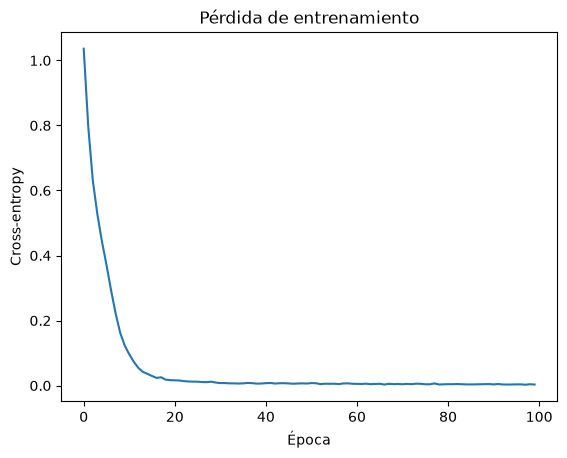

In [25]:
# Red neuronal para tres clases: negativo, neutral y positivo.
# CrossEntropyLoss espera logits; por eso NO se aplica ReLU ni Softmax a la salida.
# Se agregan componentes de dropout para evitar que el entrenamiento quede en mínimos locales

torch.manual_seed(42)
model = torch.nn.Sequential(
    torch.nn.Linear(L, 100),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(100, 50),
    torch.nn.ReLU(),
    torch.nn.Dropout(0.2),
    torch.nn.Linear(50, 3)
).to(device)

cross_el = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
epochs = 100

hist_loss = []
model.train()
for e in range(epochs):
    losses = []
    for x, y in train_loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        logits = model(x)
        loss = cross_el(logits, y)
        loss.backward()
        optimizer.step()
        losses.append(loss.item())
    hist_loss.append(np.mean(losses))
    if e % 10 == 0 or e == epochs - 1:
        print(f'Epoch: {e:3d}  Loss: {hist_loss[-1]:.4f}')

plt.plot(hist_loss)
plt.xlabel('Época')
plt.ylabel('Cross-entropy')
plt.title('Pérdida de entrenamiento')
plt.show()


Accuracy: 0.6309037900874636
              precision    recall  f1-score   support

           N       0.64      0.59      0.61       651
         NEU       0.17      0.12      0.14       201
           P       0.69      0.78      0.73       863

    accuracy                           0.63      1715
   macro avg       0.50      0.50      0.50      1715
weighted avg       0.61      0.63      0.62      1715



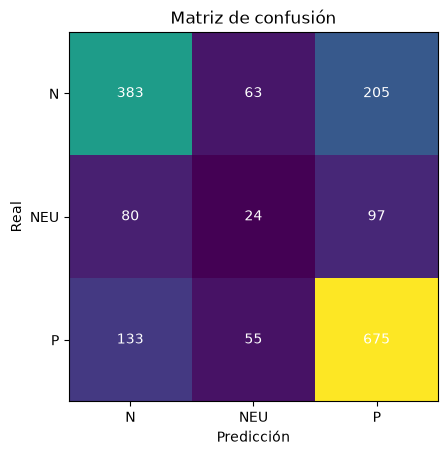

,N pred,NEU pred,P pred
N real,383,63,205
NEU real,80,24,97
P real,133,55,675


In [26]:
# Evaluación del modelo. Dropout debe estar desactivado durante inferencia.
# Se evalúa la capacidad del modelo de predecir efectivamente la polaridad de los tweets de los datos de test

from sklearn.metrics import confusion_matrix, classification_report, accuracy_score

test_loader = torch.utils.data.DataLoader(data_test, batch_size=len(data_test), shuffle=False)
xi, yi = next(iter(test_loader))

model.eval()
with torch.no_grad():
    logits = model(xi.to(device))
    pred = torch.argmax(logits, dim=1).cpu().numpy()

y_true = yi.numpy()
labels_nombres = ['N', 'NEU', 'P']
M = confusion_matrix(y_true, pred, labels=[0, 1, 2])
df = pd.DataFrame(M, index=[f'{x} real' for x in labels_nombres],
                     columns=[f'{x} pred' for x in labels_nombres])

print('Accuracy:', accuracy_score(y_true, pred))
print(classification_report(y_true, pred, target_names=labels_nombres, zero_division=0))

# Matriz de confusión sin depender de seaborn.
fig, ax = plt.subplots()
im = ax.imshow(M)
ax.set_xticks(range(3), labels_nombres)
ax.set_yticks(range(3), labels_nombres)
ax.set_xlabel('Predicción')
ax.set_ylabel('Real')
ax.set_title('Matriz de confusión')
for i in range(3):
    for j in range(3):
        ax.text(j, i, M[i, j], ha='center', va='center', color='white')
plt.show()
display(df)


In [31]:
# Predicción de una frase nueva
frase = 'Me gusta comprar juguetes en la juguetería de la esquina, porque tienen buenos precios y variedad.'
tokens_frase = normalizar(frase)
texto_frase = ' '.join(tokens_frase)
print('Tokens normalizados:', tokens_frase)

# transform() usa exactamente el vocabulario aprendido durante fit().
# Los términos fuera del vocabulario se ignoran; no se crean nuevas columnas.
X_frase = vectorizer.transform([texto_frase]).toarray()
x_frase = torch.tensor(X_frase, dtype=torch.float32).to(device)

model.eval()
with torch.no_grad():
    logits = model(x_frase)
    probabilidades = torch.softmax(logits, dim=1)
    clase = torch.argmax(logits, dim=1).item()

polaridades_salida = ['Negativo', 'Neutral', 'Positivo']
print(frase)
print('Polaridad:', polaridades_salida[clase])
print('Probabilidades:', dict(zip(polaridades_salida, probabilidades.cpu().numpy()[0].round(4))))



Tokens normalizados: ['gust', 'compr', 'juguet', 'juguet', 'esquin', 'buen', 'preci', 'varied']
Me gusta comprar juguetes en la juguetería de la esquina, porque tienen buenos precios y variedad.
Polaridad: Positivo
Probabilidades: {'Negativo': np.float32(0.0), 'Neutral': np.float32(0.0006), 'Positivo': np.float32(0.9994)}
